# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph and node contexts.

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure and run

In [12]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
ABSTRACT_PATH = ASSETS_ROOT / 'abstracts' / 'pathogen_abstract_nipah_virus.txt'
ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'

abstract_text = load_text(ABSTRACT_PATH)
ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.1
RELATION_EFFORT = 1.5
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    model='gpt-4o-mini',
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
)

graphicalizer = Graphicalizer.from_openai(ontology, config)
result = graphicalizer.run(abstract_text)

In [13]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 42466a9525771b6f88f34965debc73799d4e2e4e24ceb6ba20097bf948388589
Raw validation: {'valid': True, 'connected': True, 'sparse': True, 'node_count': 10, 'edge_count': 9, 'density': 0.2, 'max_neighbor_count': 4, 'hub_nodes': (), 'issues': (), 'density_ok': True, 'hubs_ok': True}
Normalized validation: {'valid': True, 'connected': True, 'sparse': True, 'node_count': 10, 'edge_count': 9, 'density': 0.2, 'max_neighbor_count': 4, 'hub_nodes': (), 'issues': (), 'density_ok': True, 'hubs_ok': True}
Normalization report: {'policy': 'largest_component', 'component_count': 1, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9', 'e10'), 'discarded_entity_ids': (), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9'), 'discarded_relation_ids': ()}
Final validation: {'valid': True, 'connected': True, 'sparse': True, 'node_count': 10, 'edge_count': 9, 'density': 0.2, 'max_neighbor_count': 4, 'hub_nodes': (), 'issues'

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nNipah virus", shape=box];
  "e10" [label="specimen\nbat specimens", shape=box];
  "e2" [label="reservoir_host\nPteropus", shape=box];
  "e3" [label="contaminated_material\nraw date-palm sap", shape=box];
  "e4" [label="geographic_location\nBangladesh", shape=box];
  "e5" [label="clinical_syndrome\nacute febrile encephalitis cases", shape=box];
  "e6" [label="human_host\npatients", shape=box];
  "e7" [label="genomic_sequence\nviral RNA", shape=box];
  "e8" [label="immune_response\nanti-Nipah immunoglobulin M", shape=box];
  "e9" [label="investigation_entity\nenvironmental sampling", shape=box];
  "e1" -> "e3" [color="#555555", label="causes_infection"];
  "e2" -> "e1" [color="#555555", label="maintained_in"];
  "e2" -> "e10" [color="#555555", label="collected_at"];
  "e3" -> "e6" [color="#555555", label="infects"];
  "e3" -> "e7" [color="#555555", label="contaminates"];
  "e3" -> "e9" [color="#555555", label="associ

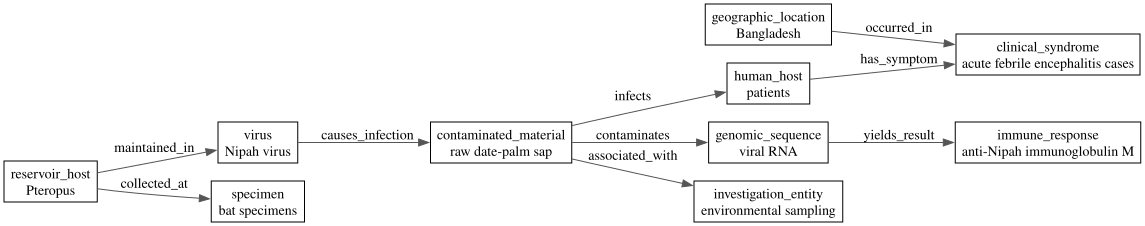

In [14]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Inspect node contexts

In [15]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {node_context.summary}')
    for evidence in node_context.evidence:
        print(f'  evidence: {evidence}')
    if node_context.uncertainty:
        print(f'  uncertainty: {node_context.uncertainty}')


[e1] Nipah virus is a zoonotic paramyxovirus that is maintained in populations of fruit bats (Pteropus) and causes infection in humans through contaminated raw date-palm sap consumption.
  evidence: Nipah virus is a zoonotic paramyxovirus maintained in populations of fruit bats of the genus Pteropus.
  evidence: The findings support a zoonotic spillover pathway in which Pteropus fruit bats contaminate raw date-palm sap, followed by infection of humans who consume the untreated product.

[e2] Pteropus fruit bats serve as a reservoir for Nipah virus, which is maintained in their populations and contaminates raw date-palm sap consumed by humans.
  evidence: Nipah virus is a zoonotic paramyxovirus maintained in populations of fruit bats of the genus Pteropus.
  evidence: bat specimens were collected under appropriate biosafety and wildlife protocols.

[e3] Raw date-palm sap is contaminated by Nipah virus through Pteropus fruit bats, leading to human infections upon consumption of the untr